# 🇮🇩 py-nusantara: Data Science & GIS Analytics Demo

This notebook demonstrates real-world data science use cases for the `py-nusantara` library. 

### Why is this library powerful for Data Scientists?
1. **Zero-DB Mode**: Fast data exploration and analytics out-of-the-box using memory-mapped gzipped CSV datasets—no PostgreSQL/MySQL/Oracle database required.
2. **Address Validation & Enrichment**: Clean up raw address inputs or geocode coordinates on the fly.
3. **Geographic Boundaries (GIS)**: Download version-locked high-resolution geographic boundaries (polygons/multipolygons) on-demand to perform spatial analysis without setting up heavy GIS servers.
4. **Pandas Integration**: Export administrative regions directly to Pandas DataFrames.

### 1. Setup & Imports

In [6]:
import py_nusantara as nus
import pandas as pd

### 2. Real Use Case 1: Market Demographics & Regional Density Analysis

**Scenario**: An e-commerce company wants to identify which provinces in Indonesia have the highest population density (people per $km^2$) to optimize their logistics hubs and warehouse locations.

With `py-nusantara`, you can load the entire administrative hierarchy into a Pandas DataFrame in a single call.

In [7]:
# Load all provinces directly as a Pandas DataFrame
df_provinces = nus.provinces_df()

# Calculate population density (people per square km)
df_provinces['pop_density'] = df_provinces['population'] / df_provinces['area']

# Display the top 10 most densely populated provinces in Indonesia
print("=== TOP 10 DENSELY POPULATED PROVINCES ===")
df_provinces_sorted = df_provinces.sort_values(by='pop_density', ascending=False)
df_provinces_sorted[['id', 'name', 'capital', 'population', 'area', 'pop_density']].head(10)

=== TOP 10 DENSELY POPULATED PROVINCES ===


,id,name,capital,population,area,pop_density
11,32,Jawa Barat,Bandung,51316378,37053.331,1384.932923
15,36,Banten,Serang,12881374,9355.763,1376.838426
13,34,Daerah Istimewa Yogyakarta,Yogyakarta,3743365,3170.363,1180.737032
12,33,Jawa Tengah,Semarang,38430645,34347.428,1118.879847
14,35,Jawa Timur,Surabaya,41919906,48055.876,872.315927
16,51,Bali,Denpasar,4375263,5582.827,783.700265
17,52,Nusa Tenggara Barat,Mataram,5751295,19631.991,292.955259
9,21,Kepulauan Riau,Tanjungpinang,2271890,8170.375,278.064348
7,18,Lampung,Bandar Lampung,9144263,33570.758,272.387743
1,12,Sumatera Utara,Medan,15640905,72437.755,215.922001


### 3. Real Use Case 2: Geolocation Enrichment (Bulk Reverse Geocoding)

**Scenario**: You have a dataset containing raw GPS coordinates of customer transaction locations. The administrative details (Province, Regency, District, Village) are missing. You need to group transactions by province for tax and regional compliance.

Using `find_by_coordinate()`, `py-nusantara` resolves coordinates to full hierarchies locally using point-in-polygon matching with centroid fallback.

In [8]:
# Mock dataset: Coordinates of customer transactions across various parts of Indonesia
transactions = pd.DataFrame({
    'transaction_id': ['TX001', 'TX002', 'TX003', 'TX004', 'TX005'],
    'customer_name': ['Ahmad', 'Budi', 'Dewi', 'Lina', 'Wayan'],
    'latitude': [-6.1754, -6.9175, -7.2575, 3.5952, -8.4095],      # Jakarta, Bandung, Surabaya, Medan, Bali
    'longitude': [106.8272, 107.6191, 112.7521, 98.6722, 115.1889]
})

# Helper function to reverse geocode a single row
def geocode_transaction(row):
    resolved = nus.find_by_coordinate(row['latitude'], row['longitude'], fallback_to_nearest=True)
    return pd.Series({
        'resolved_province': resolved['province'].name if resolved['province'] else "Unknown",
        'resolved_regency': resolved['regency'].name if resolved['regency'] else "Unknown",
        'resolved_district': resolved['district'].name if resolved['district'] else "Unknown",
        'resolved_village': resolved['village'].name if resolved['village'] else "Unknown"
    })

# Apply geocoding to the dataframe
df_enriched = pd.concat([transactions, transactions.apply(geocode_transaction, axis=1)], axis=1)
print("=== ENRICHED CUSTOMER TRANSACTIONS ===")
df_enriched

=== ENRICHED CUSTOMER TRANSACTIONS ===


,transaction_id,customer_name,latitude,longitude,resolved_province,resolved_regency,resolved_district,resolved_village
0,TX001,Ahmad,-6.1754,106.8272,Daerah Khusus Ibukota Jakarta,Kota Administrasi Jakarta Pusat,Gambir,Gambir
1,TX002,Budi,-6.9175,107.6191,Jawa Barat,Kota Bandung,Sumur Bandung,Kebon Pisang
2,TX003,Dewi,-7.2575,112.7521,Jawa Timur,Kota Surabaya,Genteng,Ketabang
3,TX004,Lina,3.5952,98.6722,Sumatera Utara,Kota Medan,Medan Petisah,Sekip
4,TX005,Wayan,-8.4095,115.1889,Bali,Kabupaten Tabanan,Marga,Tua


### 4. Real Use Case 3: GIS Boundaries & WKT (Well-Known Text) Conversion

**Scenario**: You need to insert the boundary shape of a province (e.g. Bali) into a GIS spatial database (like PostGIS, MySQL Spatial, or BigQuery GIS) or load it into a spatial plotting library like `shapely` or `geopandas`.

By default, `py-nusantara` excludes spatial polygons to keep package size small. You can download them on-demand and convert them into the standard WKT (Well-Known Text) geometry format.

In [9]:
# 1. Dynamically enable boundary tracking in config
nus.init({
    "columns": {
        "provinces": {
            "boundary": {"enabled": True}
        }
    }
})

# 2. Download high-resolution province boundaries from CDN (securely cached on R2)
print("Downloading boundary shapefiles...")
nus.download_boundaries(levels="provinces")

# 3. Fetch Bali Province (ID: '51')
bali = nus.find_province("51")

# 4. Convert boundary JSON to standard Well-Known Text (WKT) format
wkt = nus.json_to_wkt(bali.boundary)

print(f"\nProvince: {bali.name}")
print("WKT Format (Truncated):")
print(wkt[:200] + " ... (Closed Polygon Coordinates)")


Province: Bali
WKT Format (Truncated):
POLYGON((114.519701 -8.100002, 114.503341 -8.095996, 114.524537 -8.092949, 114.519701 -8.100002), (115.234823 -8.746994, 115.224802 -8.750259, 115.218828 -8.743982, 115.224463 -8.729553, 115.237886 -8 ... (Closed Polygon Coordinates)


### 5. Hierarchical Relationship Traversal

**Scenario**: A financial application needs to build a dynamic cascading dropdown menu in a user interface (Province -> Regency -> District -> Village).

You can traverse the administrative relationship down dynamically using properties. Downstream villages are **lazy-loaded** and partitioned by Province ID to maintain a tiny memory footprint.

In [10]:
# Find Bali Province
bali = nus.find_province("51")
print(f"Selected Province: {bali.name}")

# Get all regencies in Bali
regencies = bali.regencies
print(f"  - Total Regencies in Bali: {len(regencies)}")

# Select a Regency (e.g., Gianyar)
gianyar = next(r for r in regencies if "Gianyar" in r.name)
print(f"\nSelected Regency: {gianyar.name}")

# Get all districts in Gianyar
districts = gianyar.districts
print(f"  - Total Districts in Gianyar: {len(districts)}")

# Select a District (e.g., Ubud)
ubud = next(d for d in districts if "Ubud" in d.name)
print(f"\nSelected District: {ubud.name}")

# Lazy-load and fetch villages in Ubud
villages = ubud.villages
print(f"  - Total Villages in Ubud: {len(villages)}")
print("  - Sample Villages:")
for v in villages[:5]:
    print(f"    * {v.name} (Postal Code: {v.postal_code})")

Selected Province: Bali
  - Total Regencies in Bali: 9

Selected Regency: Kabupaten Gianyar
  - Total Districts in Gianyar: 7

Selected District: Ubud
  - Total Villages in Ubud: 8
  - Sample Villages:
    * Ubud (Postal Code: 80571)
    * Lodtunduh (Postal Code: 80571)
    * Mas (Postal Code: 80571)
    * Singakerta (Postal Code: 80571)
    * Kedewatan (Postal Code: 80571)


### 6. Geographic Boundary Visualization (Matplotlib)

**Scenario**: Verify and display the geographic shape of administrative regions (such as Bali Province) directly in the notebook using standard data science plotting libraries.

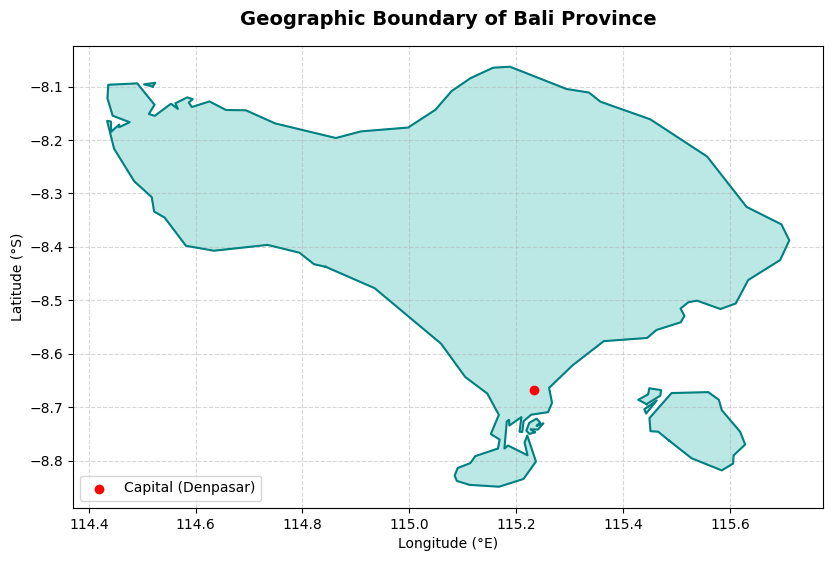

In [11]:
import json
try:
    import matplotlib.pyplot as plt
    
    # 1. Fetch Bali province boundary coordinates
    bali = nus.find_province("51")
    polygon_data = json.loads(bali.boundary)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Recursive helper to plot nested coordinates (handling both Polygon & MultiPolygon)
    def plot_geom(geom, ax):
        if isinstance(geom[0][0], list):
            for part in geom:
                plot_geom(part, ax)
        else:
            # Extract Lat/Lon coordinates
            lats = [coord[0] for coord in geom]
            lons = [coord[1] for coord in geom]
            
            # Plot outline and fill region
            ax.plot(lons, lats, color="#008080", linewidth=1.5)
            ax.fill(lons, lats, color="#20b2aa", alpha=0.3)
            
    plot_geom(polygon_data, ax)
    
    # Set map metadata
    ax.set_title(f"Geographic Boundary of {bali.name} Province", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°S)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_aspect("equal")
    
    # Label key cities/centroids
    ax.scatter([bali.longitude], [bali.latitude], color="red", zorder=5, label=f"Capital ({bali.capital})")
    ax.legend(loc="lower left")
    
    plt.show()
except ImportError:
    print("Visualization skipped. Please install matplotlib to view the boundary map:")
    print("  pip install matplotlib")